In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from IPython.display import display
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, confusion_matrix, ConfusionMatrixDisplay, make_scorer
from imblearn.over_sampling import SMOTE

# Preprocessing Data

In [21]:
data = pd.read_csv('breastCancer.csv', delimiter='\t')
display(data)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,gender,Bratio
0,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,F,0.162878
1,84300903,M,19.69,21.25,130,1203,0.1096,0.1599,0.1974,0.1279,...,152.5,1709,0.1444,0.4245,0.4504,0.243,0.3613,0.08758,F,0.751106
2,84348301,M,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,F,0.465537
3,84358402,M,20.29,14.34,135.1,1297,0.1003,0.1328,0.198,0.1043,...,152.2,1575,0.1374,0.205,0.4,0.1625,0.2364,0.07678,F,0.969993
4,844359,M,18.25,-19.98,119.6,1040,0.09463,0.109,0.1127,0.074,...,153.2,1606,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,F,0.552544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,925277,B,14.59,22.68,96.39,657.1,0.08473,0.133,0.1029,0.03736,...,105.9,733.5,0.1026,0.3171,0.3662,0.1105,0.2258,0.08004,F,0.685894
565,925291,B,11.51,23.93,74.52,403.5,0.09261,0.1021,0.1112,0.04105,...,82.28,474.2,0.1298,0.2517,0.363,0.09653,0.2112,0.08732,F,0.515357
566,926125,M,20.92,25.09,143,1347,0.1099,0.2236,0.3174,0.1474,...,179.1,1819,0.1407,0.4186,0.6599,0.2542,0.2929,0.09873,F,0.928376
567,926424,M,21.56,22.39,142,1479,0.111,0.1159,0.2439,0.1389,...,166.1,2027,0.141,0.2113,0.4107,0.2216,0.206,0.07115,F,0.765866


In [22]:
# Set X and y for training of models

y = data['diagnosis']
data = data.drop('diagnosis', axis=1)

In [23]:
print(data.columns)

Index(['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'gender', 'Bratio'],
      dtype='object')


In [24]:
# Drop one valued features and id which is a unique identifier.

#data['gender'].unique() 
data = data.drop('gender', axis=1)
data = data.drop('id', axis=1)

In [25]:
# Before fixing missing numbers

sum = 0
for col in list(data.columns):
    numeric_column = pd.to_numeric(data[col], errors='coerce')
    missing_count = np.isnan(numeric_column).sum()
    sum+=missing_count
    print(f'{col}\t Missing value count: {missing_count}')
print('\n')
print(f'Sum of missing numbers: {sum}\n')
print(f'Percentage of missing numbers: {(sum/(data.shape[0]+data.shape[1])*100)}%')

radius_mean	 Missing value count: 6
texture_mean	 Missing value count: 5
perimeter_mean	 Missing value count: 2
area_mean	 Missing value count: 6
smoothness_mean	 Missing value count: 2
compactness_mean	 Missing value count: 4
concavity_mean	 Missing value count: 7
concave points_mean	 Missing value count: 2
symmetry_mean	 Missing value count: 6
fractal_dimension_mean	 Missing value count: 2
radius_se	 Missing value count: 3
texture_se	 Missing value count: 3
perimeter_se	 Missing value count: 4
area_se	 Missing value count: 4
smoothness_se	 Missing value count: 4
compactness_se	 Missing value count: 6
concavity_se	 Missing value count: 5
concave points_se	 Missing value count: 4
symmetry_se	 Missing value count: 6
fractal_dimension_se	 Missing value count: 7
radius_worst	 Missing value count: 4
texture_worst	 Missing value count: 8
perimeter_worst	 Missing value count: 3
area_worst	 Missing value count: 6
smoothness_worst	 Missing value count: 3
compactness_worst	 Missing value count:

In [26]:
# Fixing missing numbers
for col in list(data.columns):
    data[col] = pd.to_numeric(data[col], errors='coerce')
    data[col] = data[col].fillna(np.mean(data[col]))
    print(f'{col}\t Missing value count: {np.isnan(data[col]).sum()}')

radius_mean	 Missing value count: 0
texture_mean	 Missing value count: 0
perimeter_mean	 Missing value count: 0
area_mean	 Missing value count: 0
smoothness_mean	 Missing value count: 0
compactness_mean	 Missing value count: 0
concavity_mean	 Missing value count: 0
concave points_mean	 Missing value count: 0
symmetry_mean	 Missing value count: 0
fractal_dimension_mean	 Missing value count: 0
radius_se	 Missing value count: 0
texture_se	 Missing value count: 0
perimeter_se	 Missing value count: 0
area_se	 Missing value count: 0
smoothness_se	 Missing value count: 0
compactness_se	 Missing value count: 0
concavity_se	 Missing value count: 0
concave points_se	 Missing value count: 0
symmetry_se	 Missing value count: 0
fractal_dimension_se	 Missing value count: 0
radius_worst	 Missing value count: 0
texture_worst	 Missing value count: 0
perimeter_worst	 Missing value count: 0
area_worst	 Missing value count: 0
smoothness_worst	 Missing value count: 0
compactness_worst	 Missing value count:

In [27]:
# Outliers ?

for col in list(data.columns):
    # IQR outlier detection
    q1 = np.nanpercentile(data[col], 25)
    q3 = np.nanpercentile(data[col], 75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    print(f'For {col} -> Lower: {lower}\tUpper: {upper}')
    col_array = np.array(data[col], dtype=float)
    print(f'Amount of outliers: {np.sum((col_array>upper)|(col_array<lower))} => {np.sum((col_array>upper)|(col_array<lower))/np.size(col_array)*100:.3f}%')
    data[col] = np.clip(data[col], lower, upper)
    col_array = np.array(data[col], dtype=float)
    print(f'Check amount of outliers after clipping: {np.sum((col_array>upper)|(col_array<lower))}\n')
    


For radius_mean -> Lower: 5.654999999999998	Upper: 21.775000000000002
Amount of outliers: 14 => 2.460%
Check amount of outliers after clipping: 0

For texture_mean -> Lower: 7.725000000000003	Upper: 30.244999999999997
Amount of outliers: 8 => 1.406%
Check amount of outliers after clipping: 0

For perimeter_mean -> Lower: 31.775000000000013	Upper: 147.49499999999998
Amount of outliers: 13 => 2.285%
Check amount of outliers after clipping: 0

For area_mean -> Lower: -122.65000000000009	Upper: 1325.75
Amount of outliers: 26 => 4.569%
Check amount of outliers after clipping: 0

For smoothness_mean -> Lower: 0.057825000000000015	Upper: 0.13394499999999998
Amount of outliers: 9 => 1.582%
Check amount of outliers after clipping: 0

For compactness_mean -> Lower: -0.03244999999999999	Upper: 0.22810999999999998
Amount of outliers: 17 => 2.988%
Check amount of outliers after clipping: 0

For concavity_mean -> Lower: -0.1169	Upper: 0.27366
Amount of outliers: 18 => 3.163%
Check amount of outliers

31


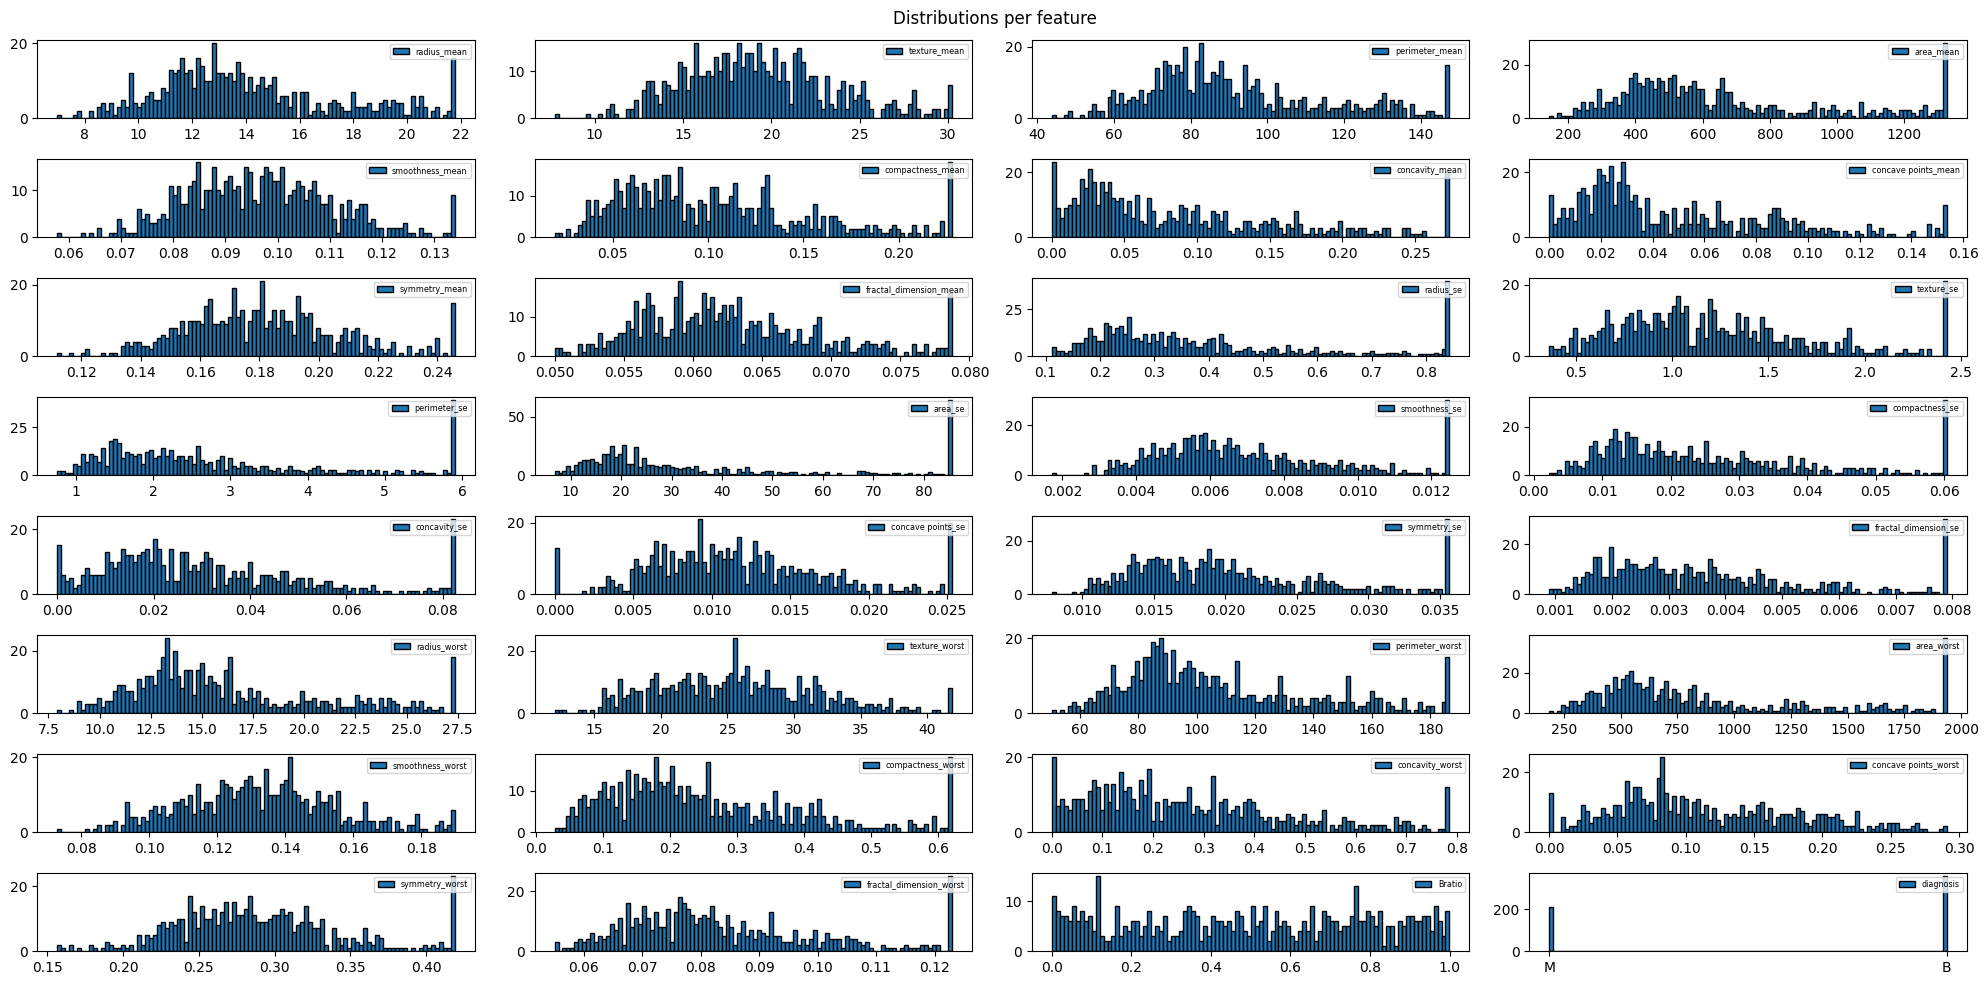

In [10]:
print(np.size(data.columns))

iterator=0
fig = plt.figure(figsize=(20, 10))
for col in list(data.columns):
    iterator+=1
    ax = fig.add_subplot(8, 4, iterator)
    ax.hist(data[col], bins=100, edgecolor='k', label=f'{col}')
    plt.legend(loc='upper right', fontsize='xx-small')
    #plt.subplots_adjust(wspace=1)
ax = fig.add_subplot(8, 4, iterator+1)
ax.hist(y, bins=100, edgecolor='k', label='diagnosis')
plt.legend(loc='upper right', fontsize='xx-small')
plt.suptitle('Distributions per feature')
plt.tight_layout()
plt.savefig('distributions_of_features.png', bbox_inches='tight', dpi=300)
plt.show()

In [28]:
# Set X for training of models
X = data

# Homogeneous Ensemble

### Inital run with DT to get a feel of best parameter values for RF

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
#print(X_train)

In [14]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
    'min_samples_split': [2, 5, 10, 15, 20, 25, 30],
    'min_samples_leaf': [1, 2, 4, 8, 10, 12, 14, 16, 18, 20],
    }

grid_search = GridSearchCV(DecisionTreeClassifier(class_weight='balanced'), param_grid, scoring='accuracy', cv=5, n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'criterion': 'entropy', 'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best cross-validation accuracy: 0.9372151898734178


Test accuracy: 0.9473684210526315
Test F1: 0.9463912946924273
Test MCC: 0.8806225488794275
[[114   1]
 [  8  48]]
<class 'sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay'>


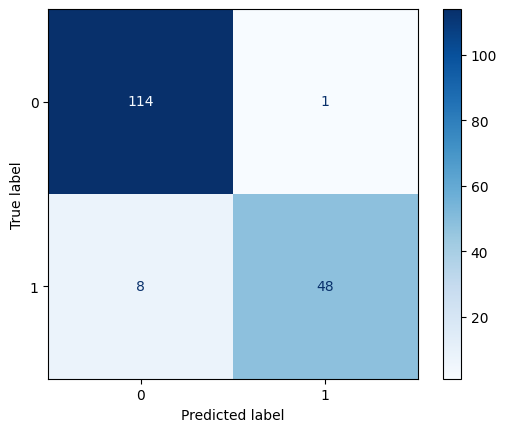

In [15]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test F1:", f1_score(y_test, y_pred, average='weighted'))
print('Test MCC:', matthews_corrcoef(y_test, y_pred))
print(cm)

disp = ConfusionMatrixDisplay(cm)
print(type(disp))
disp.plot(cmap='Blues')

In [ ]:
n_estimators = np.arange(100, 1100, 100)

scoring = {
	'accuracy': make_scorer(accuracy_score),
	'f1_weighted': make_scorer(f1_score, average='weighted'),
	'mcc': make_scorer(matthews_corrcoef)
}

results = []

for n in n_estimators:
	clf_rf = RandomForestClassifier(n, criterion='entropy', max_depth=25, oob_score=True,  min_samples_leaf=1, min_samples_split=5)
	scores = cross_validate(clf_rf, X, y, scoring=scoring, cv=10)

	clf_rf.fit(X, y)
	oob_score = clf_rf.oob_score_ # Get OOB score

	results.append({
		'n_estimators': n,
		'accuracy_mean': scores['test_accuracy'].mean(),
		'accuracy_std': scores['test_accuracy'].std(),
		'f1_weighted_mean': scores['test_f1_weighted'].mean(),
		'f1_weighted_std': scores['test_f1_weighted'].std(),
		'mcc_mean': scores['test_mcc'].mean(),
		'mcc_std': scores['test_mcc'].std(), 
		'OOB score': oob_score
	})

# Display as DataFrame
results_df = pd.DataFrame(results)
#print(results_df)
display(results_df)   

,n_estimators,accuracy_mean,accuracy_std,f1_weighted_mean,f1_weighted_std,mcc_mean,mcc_std,OOB score
0,100,0.950846,0.023886,0.950729,0.023761,0.895303,0.050913,0.954306
1,200,0.957864,0.017849,0.957679,0.017813,0.909991,0.038759,0.954306
2,300,0.952601,0.023235,0.952550,0.023048,0.899324,0.049497,0.959578
3,400,0.956125,0.027720,0.956035,0.027637,0.906715,0.059167,0.961336
4,500,0.956109,0.026576,0.956040,0.026474,0.906600,0.056779,0.957821
5,600,0.952601,0.025143,0.952499,0.025014,0.898994,0.053667,0.963093
6,700,0.957879,0.029022,0.957778,0.028942,0.910365,0.061880,0.959578
7,800,0.957879,0.026818,0.957835,0.026686,0.910499,0.057106,0.957821
8,900,0.957864,0.027933,0.957783,0.027834,0.910250,0.059608,0.957821
9,1000,0.959618,0.026925,0.959583,0.026773,0.914035,0.057331,0.961336


Test accuracy: 0.9473684210526315
Test F1 (weighted): 0.9475969145757922
Test MCC: 0.889292374786322


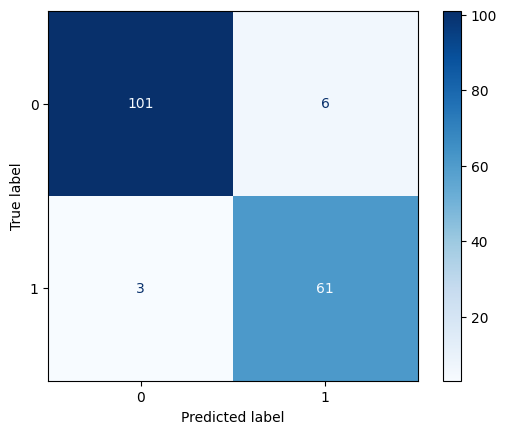

In [34]:
# Display confusion matrix and ROC curve

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

best_rf = RandomForestClassifier(
    n_estimators=1000,
    criterion='entropy',
    max_depth=25,
    min_samples_leaf=1,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=1
)

best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

# Metrics
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test F1 (weighted):", f1_score(y_test, y_pred, average='weighted'))
print("Test MCC:", matthews_corrcoef(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
#plt.title(f'Confusion Matrix – Random Forest (n_estimators={1000})')
plt.show()

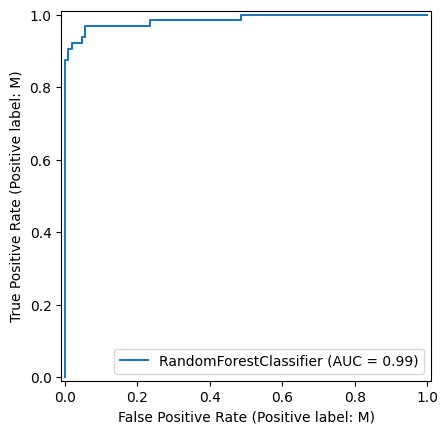

In [35]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(best_rf, X_test, y_test)
#plt.title('ROC Curve – Best Random Forest')
plt.show()

Fixing class distributions

In [36]:
from collections import Counter
# Trying to fix class skewed distributions

sm = SMOTE(sampling_strategy='minority', random_state=42)
result = sm.fit_resample(X, y)

new_X, new_y = result[0], result[1] # New X and y

print("Before SMOTE:")
print(f"  y distribution: {Counter(y)}")
print(f"  X shape: {X.shape}")

print("\nAfter SMOTE:")
print(f"  y distribution: {Counter(result[1])}")
print(f"  X shape: {result[0].shape}")


Before SMOTE:
  y distribution: Counter({'B': 357, 'M': 212})
  X shape: (569, 31)

After SMOTE:
  y distribution: Counter({'M': 357, 'B': 357})
  X shape: (714, 31)


In [45]:
X_train, X_test, y_train, y_test = train_test_split(new_X, new_y, test_size=0.3, stratify=new_y, random_state=42)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
    'min_samples_split': [2, 5, 10, 15, 20, 25, 30],
    'min_samples_leaf': [1, 2, 4, 8, 10, 12, 14, 16, 18, 20],
    }

cv = sklearn.model_selection.StratifiedKFold(n_splits=10 ,shuffle=True, random_state=42)

grid_search = GridSearchCV(DecisionTreeClassifier(class_weight='balanced'), param_grid, scoring='accuracy', cv=cv, n_jobs=1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 15}
Best cross-validation accuracy: 0.9539591836734692


Test accuracy: 0.9023255813953488
Test F1: 0.9023255813953488
Test MCC: 0.8046902042229145
[[97 11]
 [10 97]]
<class 'sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay'>


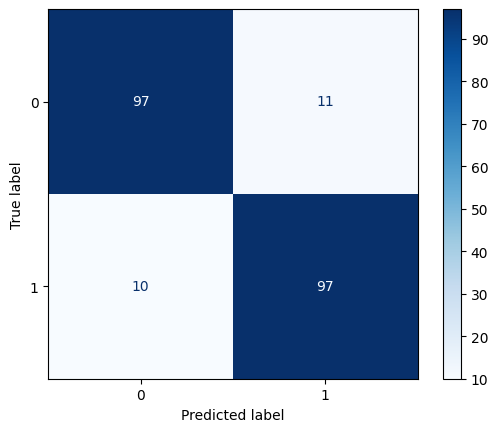

In [72]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test F1:", f1_score(y_test, y_pred, average='weighted'))
print('Test MCC:', matthews_corrcoef(y_test, y_pred))
print(cm)

disp = ConfusionMatrixDisplay(cm)
print(type(disp))
disp.plot(cmap='Blues')

In [17]:
n_estimators = np.arange(100, 1100, 100)

scoring = {
	'accuracy': make_scorer(accuracy_score),
	'f1_weighted': make_scorer(f1_score, average='weighted'),
	'mcc': make_scorer(matthews_corrcoef)
}

results = []

cv = sklearn.model_selection.StratifiedKFold(n_splits=10 ,shuffle=True, random_state=42)

for n in n_estimators:
	clf_rf = RandomForestClassifier(n, criterion='entropy', max_depth=10, min_samples_leaf=4, min_samples_split=15, class_weight='balanced', oob_score=True, random_state=42, n_jobs=1)
	scores = cross_validate(clf_rf, new_X, new_y, scoring=scoring, cv=cv)
	
	clf_rf.fit(new_X, new_y)
	oob_score = clf_rf.oob_score_

	results.append({
		'n_estimators': n,
		'accuracy_mean': scores['test_accuracy'].mean(),
		'accuracy_std': scores['test_accuracy'].std(),
		'f1_weighted_mean': scores['test_f1_weighted'].mean(),
		'f1_weighted_std': scores['test_f1_weighted'].std(),
		'mcc_mean': scores['test_mcc'].mean(),
		'mcc_std': scores['test_mcc'].std(),
		'OOB': oob_score
	})

# Display as DataFrame
results_df = pd.DataFrame(results)
#print(results_df)
display(results_df)   

,n_estimators,accuracy_mean,accuracy_std,f1_weighted_mean,f1_weighted_std,mcc_mean,mcc_std,OOB
0,100,0.956592,0.023869,0.956560,0.023914,0.914355,0.046502,0.960784
1,200,0.956612,0.022976,0.956582,0.023017,0.914322,0.044887,0.960784
2,300,0.960818,0.024136,0.960790,0.024178,0.922625,0.047116,0.962185
3,400,0.960818,0.024136,0.960790,0.024178,0.922625,0.047116,0.960784
4,500,0.962226,0.019834,0.962213,0.019852,0.925061,0.039043,0.960784
5,600,0.962226,0.019834,0.962213,0.019852,0.925061,0.039043,0.960784
6,700,0.963635,0.020935,0.963621,0.020953,0.927916,0.041278,0.960784
7,800,0.962226,0.019834,0.962213,0.019852,0.925061,0.039043,0.959384
8,900,0.963635,0.020935,0.963621,0.020953,0.927916,0.041278,0.960784
9,1000,0.962226,0.019834,0.962213,0.019852,0.925061,0.039043,0.960784


Test accuracy: 0.9395348837209302
Test F1 (weighted): 0.9394799023425995
Test MCC: 0.8809724178976152


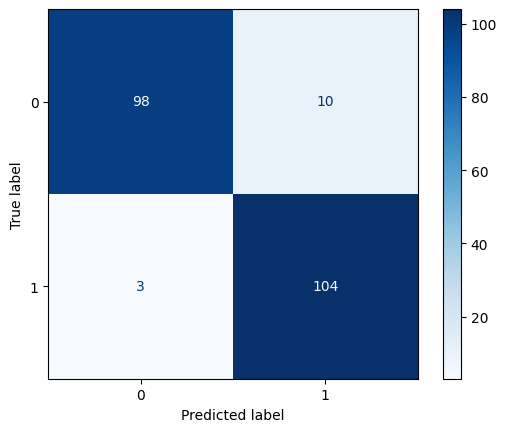

In [37]:
# Display confusion matrix and ROC curve

X_train, X_test, y_train, y_test = train_test_split(new_X, new_y, test_size=0.3, stratify=new_y, random_state=42)

best_rf = RandomForestClassifier(
    n_estimators=700,
    criterion='entropy',
    max_depth=10,
    min_samples_leaf=4,
    min_samples_split=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=1
)

best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

# Metrics
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test F1 (weighted):", f1_score(y_test, y_pred, average='weighted'))
print("Test MCC:", matthews_corrcoef(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
#plt.title(f'Confusion Matrix – Random Forest (n_estimators={700})')
plt.show()

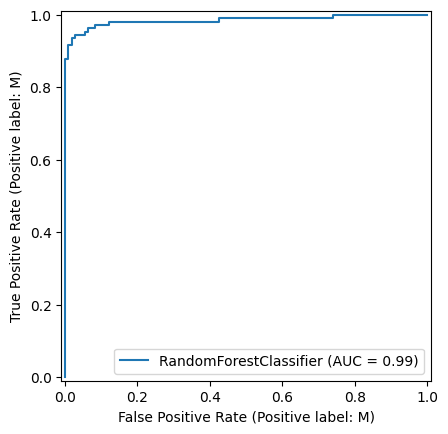

In [40]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(best_rf, X_test, y_test)
#plt.title('ROC Curve – Best Random Forest')
plt.show()


# Heterogenous Ensemble

## Inital hyperparameter tunings for algorithms

Not fixing class distribution

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Logistic Regression

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['lbfgs', 'saga'],
    'l1_ratio': [0.0, 0.5, 1.0]  # only used when penalty='elasticnet'
}

cv = sklearn.model_selection.StratifiedKFold(n_splits=10 ,shuffle=True, random_state=42)

grid_search = GridSearchCV(LogisticRegression(), param_grid_lr, scoring='accuracy', cv=cv, n_jobs=1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/line

Best parameters: {'C': 10, 'l1_ratio': 0.0, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validation accuracy: 0.9471153846153847


/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:2

In [102]:
# kNN

param_grid_knn = {
    'n_neighbors': np.arange(3, 33, 2),
    'weights': ['uniform', 'distance'], 
    'p': [1, 2, 3]
}

cv = sklearn.model_selection.StratifiedKFold(n_splits=10 ,shuffle=True, random_state=42)

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring='accuracy', cv=cv, n_jobs=1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'n_neighbors': np.int64(9), 'p': 1, 'weights': 'uniform'}
Best cross-validation accuracy: 0.9471794871794872


In [ ]:
# Decision Tree

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
    'min_samples_split': [2, 5, 10, 15, 20, 25, 30],
    'min_samples_leaf': [1, 2, 4, 8, 10, 12, 14, 16, 18, 20],
    }

cv = sklearn.model_selection.StratifiedKFold(n_splits=10 ,shuffle=True, random_state=42)

grid_search = GridSearchCV(DecisionTreeClassifier(class_weight='balanced'), param_grid_dt, scoring='accuracy', cv=cv, n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'criterion': 'entropy', 'max_depth': 40, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best cross-validation accuracy: 0.9423076923076923


In [105]:
# Gradient Boosting

param_grid_gb = {
    'n_estimators': np.arange(100, 700, 100),
    'learning_rate': [0.01, 0.05, 0.1, 0.5],#[0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5], 
    'max_depth': np.arange(2, 8, 2),
    'subsample': [0.8, 1.0]
}

cv = sklearn.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gb, scoring='accuracy', cv=cv, n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)


Best parameters: {'learning_rate': 0.05, 'max_depth': np.int64(4), 'n_estimators': np.int64(300), 'subsample': 0.8}
Best cross-validation accuracy: 0.9623101265822784


In [110]:
# SVM (RBF Kernel)

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf']
}

cv = sklearn.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(SVC(probability=True, random_state=42), param_grid_svm, scoring='accuracy', cv=cv, n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)


Best parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation accuracy: 0.934620253164557


### Build estimator using the different algorithms with best parameter values

In [42]:
best_lr = LogisticRegression(C=10, l1_ratio=0.0, penalty='l2', solver='lbfgs', max_iter=10000)  # {'C': 10, 'l1_ratio': 0.0, 'penalty': 'l2', 'solver': 'lbfgs'}
best_knn = KNeighborsClassifier(n_neighbors=9, p=1, weights='uniform')  # Best parameters: {'n_neighbors': np.int64(9), 'p': 1, 'weights': 'uniform'}
best_dt = DecisionTreeClassifier(criterion='entropy', max_depth=40, min_samples_leaf=4, min_samples_split=2) # Best parameters: {'criterion': 'entropy', 'max_depth': 40, 'min_samples_leaf': 4, 'min_samples_split': 2}
best_gb = GradientBoostingClassifier(learning_rate=0.05, max_depth=4, n_estimators=300, subsample=0.8) # Best parameters: {'learning_rate': 0.05, 'max_depth': np.int64(4), 'n_estimators': np.int64(300), 'subsample': 0.8}
best_svm = SVC(C=100, gamma='scale', kernel='rbf', probability=True, random_state=42) # Best parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}

estimators = [
    ('lr', best_lr), 
    ('knn', best_knn),
    ('dt', best_dt),
    ('gb', best_gb), 
    ('svm', best_svm)
]

est_cl = VotingClassifier(estimators=estimators, voting='soft', weights=[1, 1, 1, 2, 1] , n_jobs=-1)

In [43]:
results_het = []

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1_weighted': make_scorer(f1_score, average='weighted'),
    'mcc': make_scorer(matthews_corrcoef)
}

scores = cross_validate(estimator=est_cl, X=X, y=y, scoring=scoring, cv=10)

results_het.append({
		'accuracy_mean': scores['test_accuracy'].mean(),
		'accuracy_std': scores['test_accuracy'].std(),
		'f1_weighted_mean': scores['test_f1_weighted'].mean(),
		'f1_weighted_std': scores['test_f1_weighted'].std(),
		'mcc_mean': scores['test_mcc'].mean(),
		'mcc_std': scores['test_mcc'].std()
	})

# Display as DataFrame
results_het = pd.DataFrame(results_het)
#print(results_df)
display(results_het)   

/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul

,accuracy_mean,accuracy_std,f1_weighted_mean,f1_weighted_std,mcc_mean,mcc_std
0,0.956078,0.037817,0.955664,0.03839,0.905775,0.082077


/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul

Accuracy: 0.9590643274853801
F1 (weighted): 0.9585433724165919
MCC: 0.9069823131306091


/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


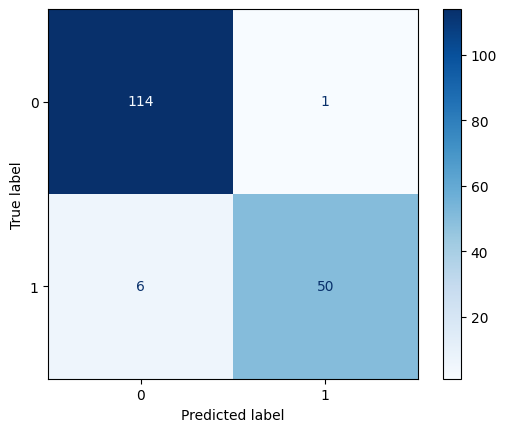

In [44]:
est_cl.fit(X_train, y_train)
y_pred_ensemble = est_cl.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_ensemble))
print("F1 (weighted):", f1_score(y_test, y_pred_ensemble, average='weighted'))
print("MCC:", matthews_corrcoef(y_test, y_pred_ensemble))

cm = confusion_matrix(y_test, y_pred_ensemble)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.show()

/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


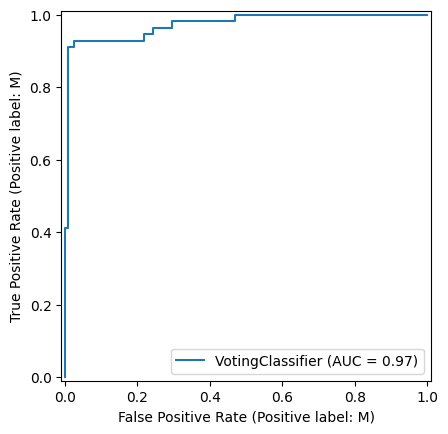

In [45]:
RocCurveDisplay.from_estimator(est_cl, X_test, y_test)
plt.show()

### Hyperparameter tuning for dataset with fixed distribution

In [46]:
from collections import Counter
# Trying to fix class skewed distributions

sm = SMOTE(sampling_strategy='minority', random_state=42)
result = sm.fit_resample(X, y)

new_X, new_y = result[0], result[1] # New X and y

print("Before SMOTE:")
print(f"  y distribution: {Counter(y)}")
print(f"  X shape: {X.shape}")

print("\nAfter SMOTE:")
print(f"  y distribution: {Counter(result[1])}")
print(f"  X shape: {result[0].shape}")

Before SMOTE:
  y distribution: Counter({'B': 357, 'M': 212})
  X shape: (569, 31)

After SMOTE:
  y distribution: Counter({'M': 357, 'B': 357})
  X shape: (714, 31)


In [47]:
X_train, X_test, y_train, y_test = train_test_split(new_X, new_y, test_size=0.3, stratify=new_y,random_state=42)

In [145]:
# Logistic Regression

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['lbfgs', 'saga'],
    'l1_ratio': [0.0, 0.5, 1.0]  # only used when penalty='elasticnet'
}

cv = sklearn.model_selection.StratifiedKFold(n_splits=10 ,shuffle=True, random_state=42)

grid_search = GridSearchCV(LogisticRegression(), param_grid_lr, scoring='accuracy', cv=cv, n_jobs=1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/line

Best parameters: {'C': 10, 'l1_ratio': 0.0, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validation accuracy: 0.9359183673469389


/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:2

In [147]:
# kNN

param_grid_knn = {
    'n_neighbors': np.arange(3, 33, 2),
    'weights': ['uniform', 'distance'], 
    'p': [1, 2, 3]
}

cv = sklearn.model_selection.StratifiedKFold(n_splits=10 ,shuffle=True, random_state=42)

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring='accuracy', cv=cv, n_jobs=1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'n_neighbors': np.int64(5), 'p': 3, 'weights': 'distance'}
Best cross-validation accuracy: 0.9399183673469389


In [148]:
# Decision Tree

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
    'min_samples_split': [2, 5, 10, 15, 20, 25, 30],
    'min_samples_leaf': [1, 2, 4, 8, 10, 12, 14, 16, 18, 20],
    }

cv = sklearn.model_selection.StratifiedKFold(n_splits=10 ,shuffle=True, random_state=42)

grid_search = GridSearchCV(DecisionTreeClassifier(class_weight='balanced'), param_grid_dt, scoring='accuracy', cv=cv, n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 15}
Best cross-validation accuracy: 0.9559591836734693


In [149]:
# Gradient Boosting

param_grid_gb = {
    'n_estimators': np.arange(100, 700, 100),
    'learning_rate': [0.01, 0.05, 0.1, 0.5],#[0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5], 
    'max_depth': np.arange(2, 8, 2),
    'subsample': [0.8, 1.0]
}

cv = sklearn.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gb, scoring='accuracy', cv=cv, n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'learning_rate': 0.1, 'max_depth': np.int64(2), 'n_estimators': np.int64(100), 'subsample': 0.8}
Best cross-validation accuracy: 0.9659797979797979


In [150]:
# SVM (RBF Kernel)

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf']
}

cv = sklearn.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(SVC(probability=True, random_state=42), param_grid_svm, scoring='accuracy', cv=cv, n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation accuracy: 0.9238585858585859


### Build estimator using the different algorithms with best parameter values using new dataset (fixed class disitribution)

In [48]:
best_lr = LogisticRegression(C=10, l1_ratio=0.0, penalty='l2', solver='lbfgs', max_iter=10000)  # {'C': 10, 'l1_ratio': 0.0, 'penalty': 'l2', 'solver': 'lbfgs'}
best_knn = KNeighborsClassifier(n_neighbors=5, p=3, weights='distance')  # Best parameters: {'n_neighbors': np.int64(5), 'p': 3, 'weights': 'distance'}
best_dt = DecisionTreeClassifier(criterion='gini', max_depth=20, min_samples_leaf=4, min_samples_split=15) # Best parameters: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 15}
best_gb = GradientBoostingClassifier(learning_rate=0.1, max_depth=2, n_estimators=100, subsample=0.8) # Best parameters: {'learning_rate': 0.1, 'max_depth': np.int64(2), 'n_estimators': np.int64(100), 'subsample': 0.8}
best_svm = SVC(C=1, gamma=0.001, kernel='rbf', probability=True, random_state=42) # Best parameters: {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}

estimators = [
    ('lr', best_lr), 
    ('knn', best_knn),
    ('dt', best_dt),
    ('gb', best_gb), 
    ('svm', best_svm)
]

est_cl = VotingClassifier(estimators=estimators, voting='soft', weights=[1, 1, 1, 2, 1] , n_jobs=-1)

In [49]:
results_het = []

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1_weighted': make_scorer(f1_score, average='weighted'),
    'mcc': make_scorer(matthews_corrcoef)
}

scores = cross_validate(estimator=est_cl, X=X, y=y, scoring=scoring, cv=10)

results_het.append({
		'accuracy_mean': scores['test_accuracy'].mean(),
		'accuracy_std': scores['test_accuracy'].std(),
		'f1_weighted_mean': scores['test_f1_weighted'].mean(),
		'f1_weighted_std': scores['test_f1_weighted'].std(),
		'mcc_mean': scores['test_mcc'].mean(),
		'mcc_std': scores['test_mcc'].std()
	})

# Display as DataFrame
results_het = pd.DataFrame(results_het)
#print(results_df)
display(results_het)   

/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul

,accuracy_mean,accuracy_std,f1_weighted_mean,f1_weighted_std,mcc_mean,mcc_std
0,0.952538,0.036012,0.952157,0.036479,0.899093,0.07776


/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul

Accuracy: 0.958139534883721
F1 (weighted): 0.958134100929659
MCC: 0.9166450581703199


/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


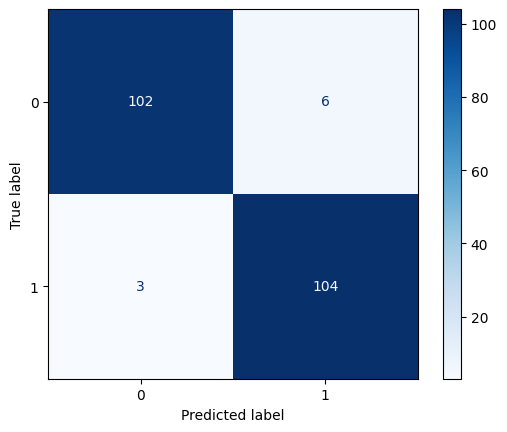

In [50]:
est_cl.fit(X_train, y_train)
y_pred_ensemble = est_cl.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_ensemble))
print("F1 (weighted):", f1_score(y_test, y_pred_ensemble, average='weighted'))
print("MCC:", matthews_corrcoef(y_test, y_pred_ensemble))

cm = confusion_matrix(y_test, y_pred_ensemble)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.show()

/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cjwessels/Documents/VS_Code/myenv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


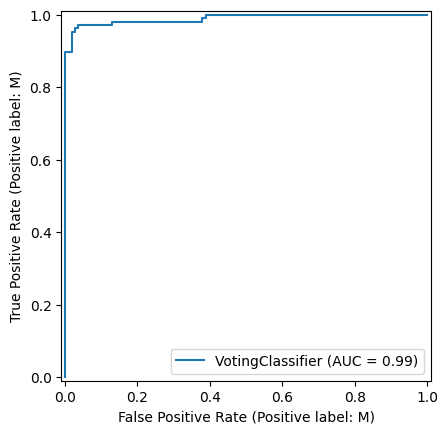

In [51]:
RocCurveDisplay.from_estimator(est_cl, X_test, y_test)
plt.show()